# Task 1: Data Preparation

In [1]:
# Import required libraries
import pandas as pd

# Load dataset
df = pd.read_csv('/content/sample_data/q2_customers.csv')

# Display first 5 rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Check shape
df.shape

# Check data types
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,0
age,0
annual_spend,0
visits_per_month,0
basket_size,0
days_since_last_visit,0
num_categories_purchased,0


In [3]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale all features
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

# Display scaled data
X_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Feature Scaling

- Feature scaling was applied using StandardScaler.
- K-Means clustering is distance-based and relies on Euclidean distance.
- Features with larger values (e.g., annual_spend) can dominate smaller ones (e.g., visits_per_month).
- Scaling ensures all features contribute equally to clustering.
- This improves the performance and stability of K-Means results.

# TASK 2: ELBOW METHOD

In [4]:
# Import KMeans
from sklearn.cluster import KMeans

# Store WCSS values
wcss = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

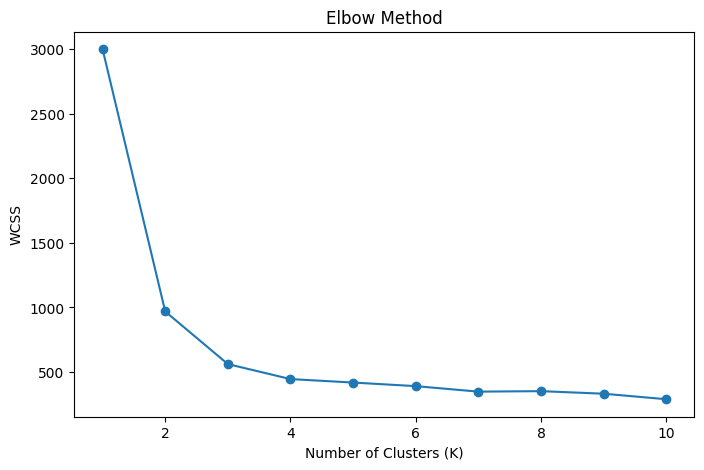

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

### Choosing Optimal K (Elbow Method)

- The Elbow Method was used to determine the optimal number of clusters.
- WCSS decreases rapidly from K = 1 to K = 3.
- After K = 3, the decrease becomes gradual, indicating diminishing returns.
- This point represents the "elbow" of the curve.
- Therefore, K = 3 is selected as the optimal number of clusters.

# TASK 3: K-MEANS CLUSTERING

In [6]:
# Apply KMeans with optimal K
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and predict clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

# View data with cluster column
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [7]:
# Get cluster centers (scaled values)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


### Cluster Interpretation

- Cluster 0: Customers who visit frequently but spend less per visit (low-value frequent shoppers).
- Cluster 1: High-value customers with high annual spending and larger basket sizes, but less frequent visits.
- Cluster 2: Average customers with moderate spending and visit frequency.

These clusters help identify different customer segments for targeted marketing strategies.

# TASK 4: PCA (Dimensionality Reduction)

In [8]:
# Import PCA
from sklearn.decomposition import PCA

# Initialize PCA (2 components)
pca = PCA(n_components=2)

# Fit and transform scaled data
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add cluster labels for later use
pca_df['cluster'] = df['cluster']

# View result
pca_df.head()

,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [9]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [10]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=X_scaled.columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### Explained Variance

- PC1 explains 83.56% of the variance.
- PC2 explains 5.57% of the variance.
- Together, they capture approximately 89% of the total variance.
- This indicates that most of the information in the dataset is preserved using just two components.

### PCA Interpretation

- PC1 is mainly influenced by features such as annual_spend, basket_size, num_categories_purchased, and days_since_last_visit.
  → It represents overall customer purchasing behavior and value.

- PC2 is strongly influenced by days_since_last_visit.
  → It represents customer recency (how recently a customer has visited).

- PCA helps reduce the dataset into fewer dimensions while preserving most of the important information.

# TASK 5: CLUSTER VISUALIZATION

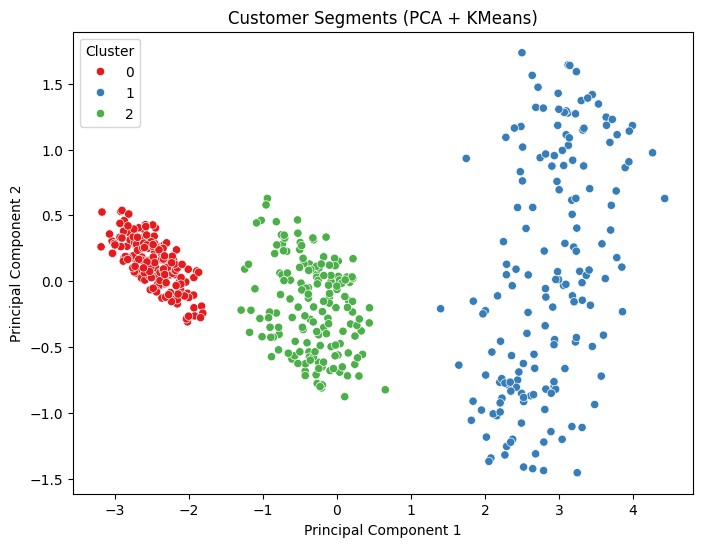

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.title('Customer Segments (PCA + KMeans)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

### Cluster Visualization

- The scatter plot shows customer segments based on PCA components.
- Each color represents a different cluster identified by K-Means.
- The clusters are clearly well-separated, especially along PC1, indicating strong segmentation.
- Cluster 1 (right side) appears to represent high-value customers, while Cluster 0 and 2 represent lower and moderate value groups.
- This visualization helps in understanding distinct customer behavior patterns for targeted business strategies.